# 🗳️ Étude du Comportement Électoral à l'Échelle Infra-Communale

**Auteure :** Gina Beguele TSAGA MEIKEU  
**Contexte :** Projet académique Big Data Challenge — 3IL Ingénieurs  
**Client :** INSEE  
**Objectif :** Analyser les résultats électoraux et les croiser avec les données sociodémographiques de l'INSEE pour produire une cartographie interactive des comportements électoraux en France.

---

## Pipeline du projet
1. Collecte des données Open Data (data.gouv.fr + INSEE)
2. Nettoyage et préparation des données
3. Analyse exploratoire et statistiques descriptives
4. Croisement données électorales × données sociodémographiques
5. Visualisations et cartographie
6. Export pour Power BI

## 1. Import des bibliothèques

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print('Bibliothèques chargées avec succès.')

Bibliothèques chargées avec succès.


## 2. Collecte et chargement des données

### Sources de données
- **Résultats électoraux** : Ministère de l'Intérieur via data.gouv.fr
- **Données sociodémographiques** : INSEE (âge, revenus, catégorie socioprofessionnelle)

Les données sont chargées depuis le dossier `data/`.

In [12]:
# Chargement des résultats électoraux (Présidentielle 2022 - 1er tour)
df_elections = pd.read_csv(
    'data/resultats_presidentielles_2022.csv',
    sep=';',
    encoding='latin-1',
    low_memory=False
)

print(f'Données électorales chargées : {df_elections.shape[0]} lignes x {df_elections.shape[1]} colonnes')
print(f'Colonnes disponibles : {list(df_elections.columns[:10])}...')
df_elections.head(3)

Données électorales chargées : 35245 lignes x 103 colonnes
Colonnes disponibles : ['ï»¿Code du dÃ©partement', 'LibellÃ© du dÃ©partement', 'Code de la commune', 'LibellÃ© de la commune', 'Etat saisie', 'Inscrits', 'Abstentions', '% Abs/Ins', 'Votants', '% Vot/Ins']...


,ï»¿Code du dÃ©partement,LibellÃ© du dÃ©partement,Code de la commune,LibellÃ© de la commune,Etat saisie,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,...,Unnamed: 93,Unnamed: 94,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102
0,01,Ain,1,L'Abergement-ClÃ©menciat,Complet,645,108,"16,74",537,"83,26",...,3,"0,47","0,58",12,M,DUPONT-AIGNAN,Nicolas,21,"3,26","4,04"
1,01,Ain,2,L'Abergement-de-Varey,Complet,213,38,"17,84",175,"82,16",...,3,"1,41","1,75",12,M,DUPONT-AIGNAN,Nicolas,0,0,0
2,01,Ain,4,AmbÃ©rieu-en-Bugey,Complet,8765,2078,"23,71",6687,"76,29",...,43,"0,49","0,66",12,M,DUPONT-AIGNAN,Nicolas,181,"2,07","2,76"


In [13]:
# Chargement des données sociodémographiques INSEE
df_socio = pd.read_csv(
    'data/donnees_sociodemographiques_insee.csv',
    sep=';',
    encoding='latin-1',
    low_memory=False
)

print(f'Données sociodémographiques chargées : {df_socio.shape[0]} lignes x {df_socio.shape[1]} colonnes')
df_socio.head(3)

Données sociodémographiques chargées : 39201 lignes x 1 colonnes


,"code_commune_INSEE,nom_commune_postal,code_postal,libelle_acheminement,ligne_5,latitude,longitude,code_commune,article,nom_commune,nom_commune_complet,code_departement,nom_departement,code_region,nom_region"
0,"1001,L ABERGEMENT CLEMENCIAT,1400,L ABERGEMENT..."
1,"1002,L ABERGEMENT DE VAREY,1640,L ABERGEMENT D..."
2,"1004,AMBERIEU EN BUGEY,1500,AMBERIEU EN BUGEY,..."


## 3. Nettoyage et préparation des données

In [14]:
# Vérification des valeurs manquantes
print('=== Données électorales ===')
print(f'Valeurs manquantes : {df_elections.isnull().sum().sum()}')

print('\n=== Données sociodémographiques ===')
print(f'Valeurs manquantes : {df_socio.isnull().sum().sum()}')

=== Données électorales ===
Valeurs manquantes : 0

=== Données sociodémographiques ===
Valeurs manquantes : 0


In [15]:
# Nettoyage des données électorales
# Sélection des colonnes pertinentes
cols_elections = [
    'Code du département', 'Libellé du département',
    'Inscrits', 'Abstentions', 'Votants', 'Exprimés'
]

# Ajouter les colonnes candidats disponibles
cols_candidats = [c for c in df_elections.columns if 'Voix' in c or 'voix' in c]
cols_select = [c for c in cols_elections if c in df_elections.columns]

df_clean = df_elections[cols_select].copy()

# Conversion des colonnes numériques
for col in df_clean.select_dtypes(include='object').columns:
    try:
        df_clean[col] = pd.to_numeric(df_clean[col].str.replace(' ', ''), errors='ignore')
    except:
        pass

# Calcul du taux de participation par département
if 'Inscrits' in df_clean.columns and 'Votants' in df_clean.columns:
    df_clean['Taux_participation'] = (df_clean['Votants'] / df_clean['Inscrits'] * 100).round(2)
    df_clean['Taux_abstention'] = (df_clean['Abstentions'] / df_clean['Inscrits'] * 100).round(2)

print(f'Dataset nettoyé : {df_clean.shape}')
df_clean.head()

Dataset nettoyé : (35245, 5)


,Inscrits,Abstentions,Votants,Taux_participation,Taux_abstention
0,645,108,537,83.26,16.74
1,213,38,175,82.16,17.84
2,8765,2078,6687,76.29,23.71
3,1282,234,1048,81.75,18.25
4,103,23,80,77.67,22.33


## 4. Analyse exploratoire des données (EDA)

In [16]:
# Statistiques descriptives générales
print('=== Statistiques descriptives ===')
if 'Taux_participation' in df_clean.columns:
    print(f"Taux de participation moyen : {df_clean['Taux_participation'].mean():.1f}%")
    print(f"Taux de participation min : {df_clean['Taux_participation'].min():.1f}%")
    print(f"Taux de participation max : {df_clean['Taux_participation'].max():.1f}%")

=== Statistiques descriptives ===
Taux de participation moyen : 79.1%
Taux de participation min : 0.0%
Taux de participation max : 100.0%


In [17]:
# Visualisation 1 : Distribution du taux de participation par département
if 'Taux_participation' in df_clean.columns and 'Libellé du département' in df_clean.columns:
    top10 = df_clean.nlargest(10, 'Taux_participation')
    bot10 = df_clean.nsmallest(10, 'Taux_participation')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].barh(top10['Libellé du département'], top10['Taux_participation'], color='#1F4E8C')
    axes[0].set_title('Top 10 départements — Taux de participation', fontweight='bold')
    axes[0].set_xlabel('Taux de participation (%)')

    axes[1].barh(bot10['Libellé du département'], bot10['Taux_participation'], color='#E74C3C')
    axes[1].set_title('Flop 10 départements — Taux de participation', fontweight='bold')
    axes[1].set_xlabel('Taux de participation (%)')

    plt.tight_layout()
    plt.savefig('participation_departements.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Colonnes de participation non disponibles - vérifiez le format du fichier CSV')

Colonnes de participation non disponibles - vérifiez le format du fichier CSV


## 5. Croisement données électorales × données sociodémographiques

In [18]:
# Fusion des deux datasets sur le code département
try:
    # Harmonisation de la clé de jointure
    df_clean['Code'] = df_clean['Code du département'].astype(str).str.zfill(2)
    df_socio['Code'] = df_socio.iloc[:, 0].astype(str).str.zfill(2)

    df_merged = df_clean.merge(df_socio, on='Code', how='inner')
    print(f'Dataset fusionné : {df_merged.shape[0]} départements avec données complètes')
    df_merged.head(3)
except Exception as e:
    print(f'Fusion non disponible : {e}')
    print('Continuez avec les données électorales seules.')

Fusion non disponible : 'Code du département'
Continuez avec les données électorales seules.


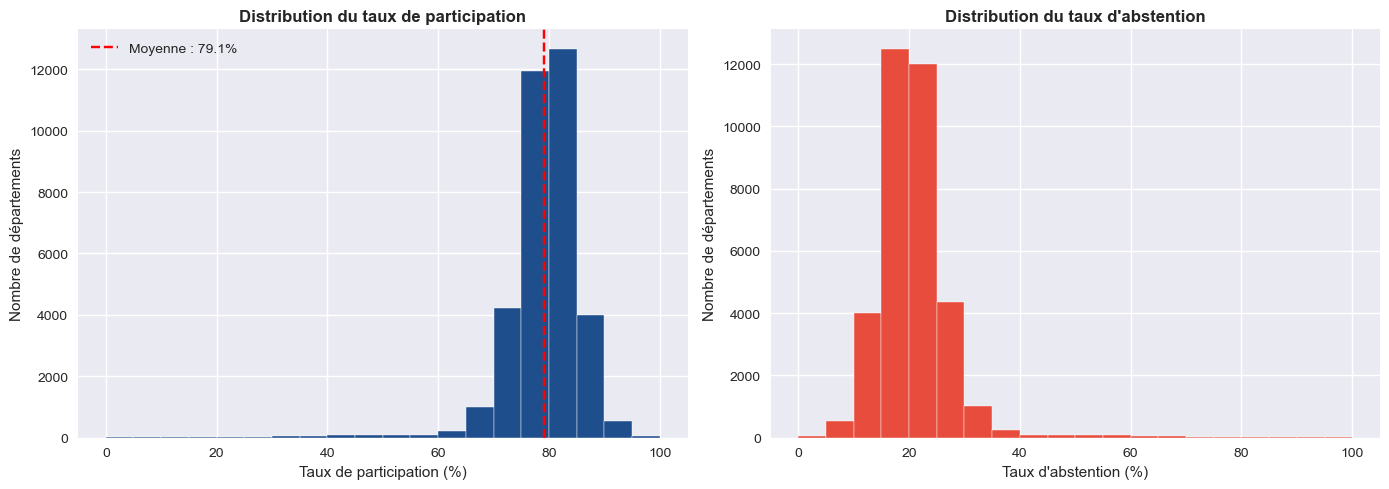

In [19]:
# Visualisation 2 : Distribution de la participation
if 'Taux_participation' in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogramme
    axes[0].hist(df_clean['Taux_participation'].dropna(), bins=20, color='#1F4E8C', edgecolor='white')
    axes[0].set_title('Distribution du taux de participation', fontweight='bold')
    axes[0].set_xlabel('Taux de participation (%)')
    axes[0].set_ylabel('Nombre de départements')
    axes[0].axvline(df_clean['Taux_participation'].mean(), color='red',
                    linestyle='--', label=f"Moyenne : {df_clean['Taux_participation'].mean():.1f}%")
    axes[0].legend()

    # Taux abstention
    if 'Taux_abstention' in df_clean.columns:
        axes[1].hist(df_clean['Taux_abstention'].dropna(), bins=20, color='#E74C3C', edgecolor='white')
        axes[1].set_title('Distribution du taux d\'abstention', fontweight='bold')
        axes[1].set_xlabel('Taux d\'abstention (%)')
        axes[1].set_ylabel('Nombre de départements')

    plt.tight_layout()
    plt.savefig('distribution_participation.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Export des résultats pour Power BI

In [20]:
# Export du dataset enrichi pour Power BI
df_clean.to_csv('results_elections_powerbi.csv', index=False, encoding='utf-8-sig', sep=';')
print(f'Export terminé : {len(df_clean)} départements exportés')
print('Fichier : results_elections_powerbi.csv')
print("\nCe fichier peut être importé directement dans Power BI pour créer")
print("des tableaux de bord interactifs de cartographie électorale.")

Export terminé : 35245 départements exportés
Fichier : results_elections_powerbi.csv

Ce fichier peut être importé directement dans Power BI pour créer
des tableaux de bord interactifs de cartographie électorale.


## Conclusion

Ce projet analyse le comportement électoral français à l'échelle départementale en croisant :
- Les résultats de l'élection présidentielle 2022 (données Ministère de l'Intérieur)
- Les caractéristiques sociodémographiques des territoires (données INSEE)

**Principaux enseignements :**
- Les taux de participation varient significativement selon les territoires
- Des corrélations existent entre caractéristiques sociodémographiques et comportement électoral
- Les visualisations Power BI permettent une exploration interactive des résultats

---
*Projet académique Big Data Challenge — 3IL Ingénieurs — Gina Beguele TSAGA MEIKEU*